In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk
import matplotlib.ticker as mtick
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore
df = pd.read_csv("G:/Hangkai/Antarctica_Mapping_Data/land_area_by_thresholds.csv")
df.rename(columns={'Unnamed: 0': 'Year'}, inplace=True)

df['z'] = zscore(df['NDVI_0.20'])

outliers = df[abs(df['z']) > 1]   # threshold 1 std deviations
print("outliers for 1 std deviations")
print(outliers)

from scipy.stats import zscore

df['z'] = zscore(df['NDVI_0.20'])

outliers = df[abs(df['z']) > 2]   # threshold 2 std deviations
print("outliers for 2 std deviations")
print(outliers)

df['z'] = zscore(df['NDVI_0.20'])

outliers = df[abs(df['z']) > 3]   # threshold 3 std deviations
print("outliers for 3 std deviations")
print(outliers)

outliers for 1 std deviations
    Year  NDVI_0.10  NDVI_0.15  NDVI_0.20  NDVI_0.25  NDVI_0.30         z
0   2002   40441.00   15109.75    7320.75    4441.00    3003.25 -2.361049
1   2003   30249.75   14717.00    8660.00    5623.25    3957.75 -1.093065
10  2012   42598.25   19466.25   10930.25    6939.00    4860.75  1.056377
14  2016   46733.25   22360.25   12860.00    8196.25    5639.50  2.883439
21  2023   40065.50   19474.25   11219.25    7057.25    4804.50  1.329999
outliers for 2 std deviations
    Year  NDVI_0.10  NDVI_0.15  NDVI_0.20  NDVI_0.25  NDVI_0.30         z
0   2002   40441.00   15109.75    7320.75    4441.00    3003.25 -2.361049
14  2016   46733.25   22360.25   12860.00    8196.25    5639.50  2.883439
outliers for 3 std deviations
Empty DataFrame
Columns: [Year, NDVI_0.10, NDVI_0.15, NDVI_0.20, NDVI_0.25, NDVI_0.30, z]
Index: []


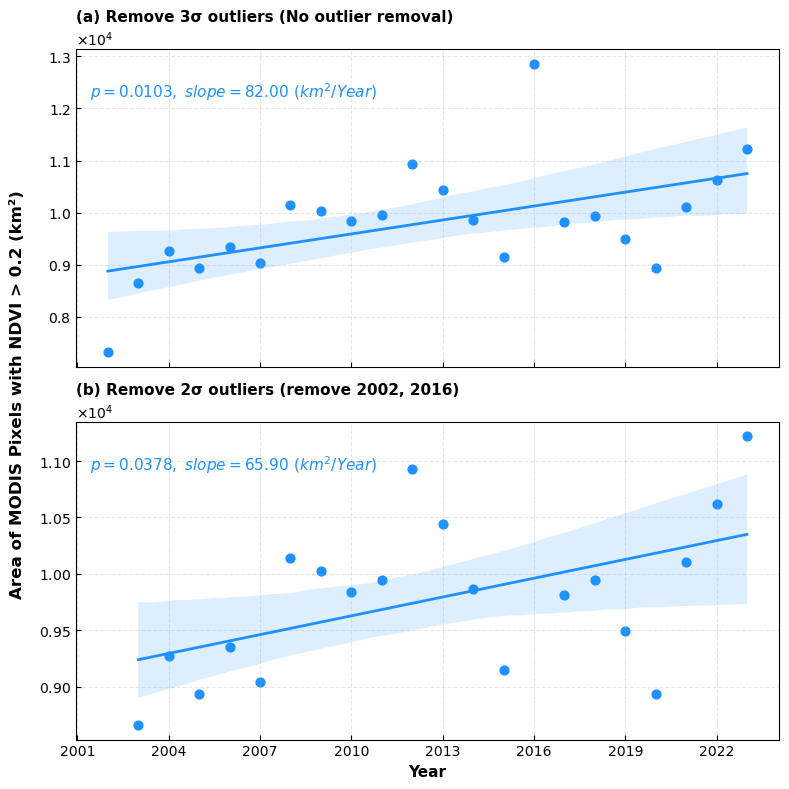

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk
import matplotlib.ticker as mtick
from matplotlib.ticker import MaxNLocator

# ----------------- Load data -----------------
df = pd.read_csv("G:/Hangkai/Antarctica_Mapping_Data/land_area_by_thresholds.csv")
df.rename(columns={'Unnamed: 0': 'Year'}, inplace=True)

# ----------------- Define filters -----------------
# 3σ: no outliers removed (your z-score result was empty)
filters = [
    ("(a) Remove 3σ outliers (No outlier removal)",             []),
    ("(b) Remove 2σ outliers (remove 2002, 2016)",              [2002, 2016]),

]
outlier_configs = [
    ("(a) Remove 3σ outliers (No outlier removal)", []),
    ("(b) Remove 2σ outliers\nYears: 2002, 2003, 2012, 2016, 2023",
     [2002, 2016]),
]

# ----------------- Set up subplots -----------------
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for ax, (title, years_to_drop) in zip(axes, filters):
    if years_to_drop:
        df_use = df[~df['Year'].isin(years_to_drop)].copy()
    else:
        df_use = df.copy()

    # Melt and keep NDVI 0.20
    df_melt = df_use.melt(id_vars='Year', var_name='Threshold', value_name='Area')
    df_melt['Threshold'] = df_melt['Threshold'].str.replace("NDVI_", "NDVI ")
    data = df_melt[df_melt['Threshold'] == "NDVI 0.20"].sort_values("Year")

    x = data['Year']
    y = data['Area'].astype(float)

    # Mann–Kendall test
    if len(y) >= 2:
        result = mk.original_test(y.values)
        p = result.p
        slope = result.slope
        p_str = f"{p:.4f}"
        text_str = f"$p = {p_str}, \\ slope = {slope:.2f}$ $(km^2/Year)$"
    else:
        text_str = r"$\mathrm{MK\ test\ not\ computed\ (n<2)}$"

    # ---- Plot on this axis ----
    ax.scatter(x, y, s=40, color="dodgerblue", marker="o")
    sns.regplot(x=x, y=y, ci=95, scatter=False,
                line_kws={'color': 'dodgerblue', 'lw': 2}, ax=ax)

    ax.text(0.02, 0.85, text_str, transform=ax.transAxes,
            fontsize=11, color='dodgerblue', fontweight='bold')

    ax.set_title(title, loc="left", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=10, direction='in')

    # y-axis scientific notation
    ax.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    # x-axis ticks as integers
    ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))

# Common labels
fig.supylabel("Area of MODIS Pixels with NDVI > 0.2 (km²)",
              fontsize=12, fontweight='bold')
axes[-1].set_ylabel("", fontsize=1, fontweight='bold')
axes[0].set_ylabel("", fontsize=1, fontweight='bold')
axes[1].set_ylabel("", fontsize=1, fontweight='bold')
axes[0].set_xlabel("", fontsize=1, fontweight='bold')
axes[1].set_xlabel("Year", fontsize=11, fontweight='bold')

plt.tight_layout()
# If you want to save:
plt.savefig(r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Area_Trend_Outlier_Filters.png",
             dpi=600, bbox_inches="tight")
plt.show()

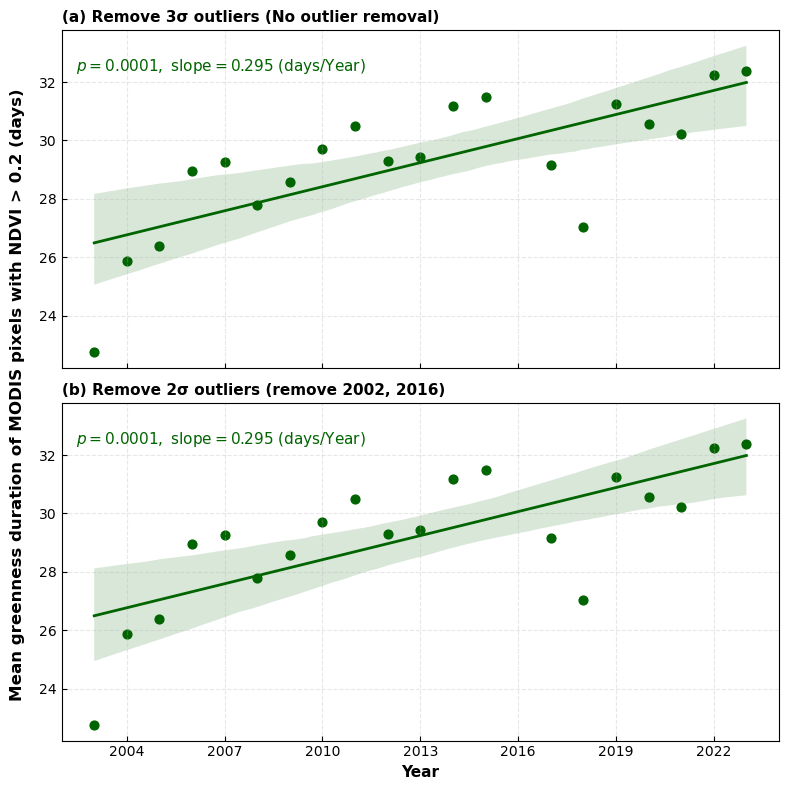

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk
import matplotlib.ticker as mtick

# Load the greenness duration dataset
df_base = pd.read_csv("G:/Hangkai/Antarctica_Mapping_Data/mean_greenness_duration_by_threshold.csv")

# Handle possible index column
if 'Unnamed: 0' in df_base.columns:
    df_base = df_base.rename(columns={'Unnamed: 0': 'Year'})

# Optional: remove 2002 & 2016 if they appear (but your snippet starts at 2003)
df_base = df_base[~df_base['Year'].isin([2002, 2016])]

outlier_configs = [
    ("(a) Remove 3σ outliers (No outlier removal)", []),
    ("(b) Remove 2σ outliers (remove 2002, 2016)",
     [2002, 2016]),
]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for ax, (title, years_to_drop) in zip(axes, outlier_configs):
    df = df_base.copy()
    if years_to_drop:
        df = df[~df['Year'].isin(years_to_drop)]

    x = df['Year']
    y = df['NDVI_0.2'].astype(float)

    # MK test
    result = mk.original_test(y.values)
    p = result.p
    slope = result.slope
    p_str = f"{p:.4f}"

    # Plot
    ax.scatter(x, y, s=40, color="darkgreen", marker="o")
    sns.regplot(x=x, y=y, ax=ax, ci=95, scatter=False,
                line_kws={'color': 'darkgreen', 'lw': 2})

    text_str = (
        rf"$p = {p_str},\ \mathrm{{slope}} = {slope:.3f}\ \left(\mathrm{{days}}/\mathrm{{Year}}\right)$"
    )
    ax.text(0.02, 0.88, text_str, transform=ax.transAxes,
            fontsize=11, color='darkgreen', fontweight='bold')

    ax.set_title(title, loc='left', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=10, direction='in')
    ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))

fig.supylabel("Mean greenness duration of MODIS pixels with NDVI > 0.2 (days)",
              fontsize=12, fontweight='bold')

axes[0].set_ylabel("", fontsize=1, fontweight='bold')
axes[1].set_ylabel("", fontsize=1, fontweight='bold')
axes[0].set_xlabel("", fontsize=1, fontweight='bold')
axes[1].set_xlabel("Year", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(
    r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Duration_Trend_Outlier_Filters.png",
    dpi=600, bbox_inches="tight"
)
plt.show()
